# Prompt caching for coding agents · reuse the stable prefix

**Prompt caching** lets the model provider reuse the work it already did on the unchanged beginning of
a prompt. Anthropic stores the processed state of a prefix you mark with a cache breakpoint; a later
request that starts with exactly the same prefix reads that state back instead of processing those
tokens again. The model still reads your new question and still writes a fresh answer every time:
nothing about the *output* is cached.

The use case is a **coding agent for one repository** (django/django). Every turn it sends the same
instructions, the same tool definitions and the same long-term project memory (summaries of issues it
has already worked on), followed by today's issue and the developer's question. That stable part is
thousands of tokens; without caching you pay to process it on every turn.

**What you will build and measure**

- A request builder that orders the prompt as tools → instructions → project memory → *breakpoint* →
  working memory.
- Six real Claude turns: no cache, first cached turn (write), a new question (read), a new memory
  appended (partial reuse), a volatile value placed too early (no reuse), and a one-hour cache write.
- A ledger of the token counters the API reports, priced at list prices, next to what the same turns
  would cost without caching, plus the break-even point for each cache lifetime.

**What you need:** an Anthropic API key and internet access for the first download of the public
SWE-bench Lite dataset from Hugging Face. No database and no embedding model are needed here.

### Install the notebook packages

Use a **Python 3.12** kernel. Open this notebook from the `cache_techniques` folder so `requirements.txt` is available. Run the next cell before Part 1: **%pip** installs into the Python environment used by this notebook's active kernel.

`requirements.txt` installs **anthropic** for Claude, **sentence-transformers** for the open-source Hugging Face embedding model and reranker (it brings PyTorch and transformers), **oracledb** and **langchain-oracledb** for Oracle AI Database, **tavily-python** for web search, **pandas**, **pyarrow** and **huggingface_hub** for reading public Hugging Face datasets, and **numpy** and **matplotlib** for measurements and charts. It also installs JupyterLab, plus nbformat and nbclient, which `tests/run_notebooks.py` uses to run a notebook end to end.

After the first installation finishes, **restart the kernel**, then run the Parts in order. Installation needs internet access; it does not need your API keys.

In [1]:
# Install packages into this notebook's active Python kernel.
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Part 1 · How prompt caching works

## 1.1 · The idea

A transformer turns every prompt token into internal attention state (keys and values) before it can
generate. For a long prompt that is real work: it costs input-token money and adds time before the first
output token appears. If many requests begin with the same text, that work is identical every time.

Prompt caching makes the provider remember it. You mark the end of the stable part of the prompt with a
`cache_control` **breakpoint**. On the first request Anthropic processes the prefix as usual and **writes**
a cache entry for it. A later request whose prompt is identical up to that breakpoint **reads** the entry:
the prefix tokens are billed at the cache-read price and only the tokens after the breakpoint are processed
from scratch.

Three things make this different from the caches an agent keeps itself (exact answers, embeddings, tool results):

- It lives **inside the provider**, not in your application or database. You cannot list, inspect or
  delete entries; you only see the effect in the usage counters.
- It caches **computation, not answers**. Every request still generates new output, so it is safe for
  questions that need a fresh answer.
- It is priced asymmetrically. On Claude Opus 5.5 a 5-minute write costs 1.25× the input price, a
  1-hour write costs 2×, and a read costs 0.05× (USD 4, 5, 8 and 0.20 per million tokens).

## 1.2 · The request flow

The diagram shows one agent turn. The agent application builds the prompt and sends it; the provider
decides between a cache hit and a miss; the usage counters that come back are the only evidence you get.

**Figure · One agent turn with a prompt-cache breakpoint**

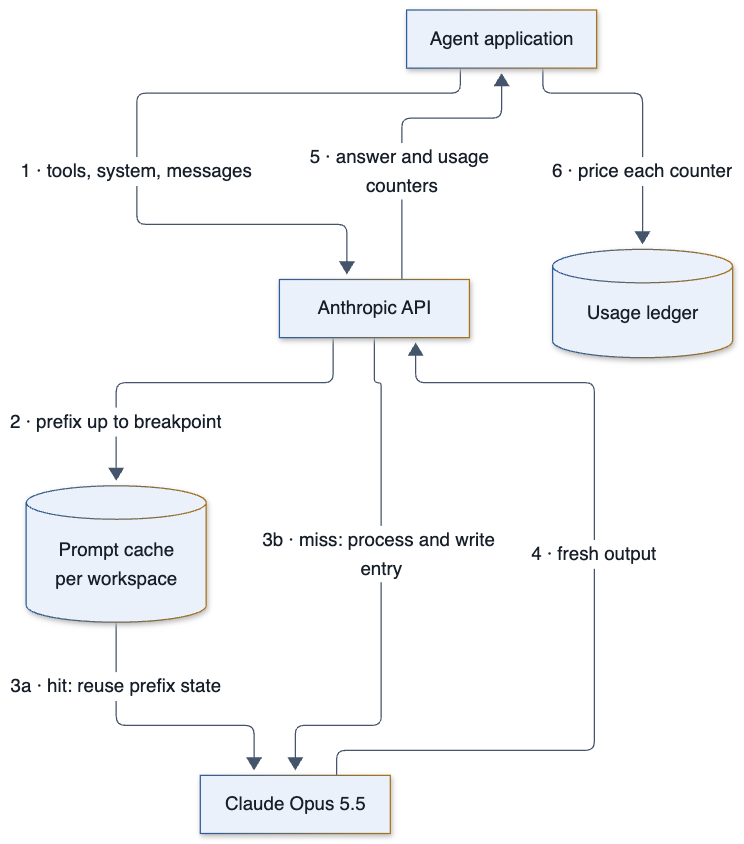

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    App["Agent application"] -->|"1 · tools, system, messages"| API["Anthropic API"]
    API -->|"2 · prefix up to breakpoint"| PC[("Prompt cache<br/>per workspace")]
    PC -->|"3a · hit: reuse prefix state"| Model["Claude Opus 5.5"]
    API -->|"3b · miss: process and write entry"| Model
    Model -->|"4 · fresh output"| API
    API -->|"5 · answer and usage counters"| App
    App -->|"6 · price each counter"| Ledger[("Usage ledger")]
```

</details>

1. **Build and send.** The application sends `tools`, `system` and `messages`. One content block carries
   `cache_control: {"type": "ephemeral"}`; everything up to and including that block is the cacheable prefix.
2. **Look up the prefix.** The API checks whether an entry exists for exactly that prefix. It also walks
   back block by block, checking at most 20 positions per breakpoint (the breakpoint itself counts as the
   first), so an entry written at an earlier breakpoint can still be found when you add blocks after it.
3. **Hit or miss.** On a hit (3a) the stored prefix state is reused and billed as
   `cache_read_input_tokens`. On a miss (3b) the prefix is processed and written, billed as
   `cache_creation_input_tokens`.
4. **Generate.** The model reads the tokens after the breakpoint (`input_tokens`) and writes a new answer
   (`output_tokens`). Output is never reused.
5. **Report.** The response carries all four counters. The three input counters add up to the full
   prompt size.
6. **Account.** Your application prices each counter separately. That ledger is how you prove the cache
   works and what it saves.

## 1.3 · What makes two requests the same

A cache hit needs a prompt that is **byte-for-byte identical** from the first token up to the breakpoint.
The prefix is assembled in a fixed order:

| Level | Contents | Changing it invalidates |
|---|---|---|
| 1 · `tools` | tool names, descriptions, input schemas | tools, system and messages caches |
| 2 · `system` | instructions, long-term memory blocks | system and messages caches |
| 3 · `messages` | conversation turns | only the messages cache |

Some request settings also take part. Changing `tool_choice` invalidates only the `messages` level; the
cached tools and system prompt stay valid. Changing thinking or effort settings always invalidates the
`messages` level, and on some models the tools and system levels too. Keep these settings constant
across turns that should share cached blocks. Other rules from the
[Anthropic prompt-caching documentation](https://platform.claude.com/docs/en/build-with-claude/prompt-caching):

- The prefix must reach the model's **minimum cacheable length**: 512 tokens on Claude Opus 5.5. A shorter
  prefix is processed normally, with no error and no cache write.
- A request can carry at most **4 breakpoints**.
- Entries are isolated **per workspace** on the Claude API; other organisations never share them.
- An entry becomes readable once the response that wrote it has *started*. Parallel requests sent at the
  same moment all miss; send one first if you need the others to hit.

So "the same request" here means: same model, same tools in the same order, and the same system text,
character for character, up to the breakpoint (plus, for cached `messages` blocks, the same
`tool_choice`, thinking and effort settings). A timestamp or a request ID anywhere in
that range makes every request unique.

## 1.4 · Freshness, expiry and invalidation

Prompt caching cannot serve stale *answers*, because it never stores answers. What can be stale is the
**prompt itself**: if your project memory changes and you keep sending the old text, the cache will happily
reuse it. Correctness is your prompt builder's job, not the cache's.

- **Lifetime.** The default entry lives 5 minutes; every read refreshes it. With
  `{"type": "ephemeral", "ttl": "1h"}` it lives an hour, at twice the input price to write. The lifetime is
  measured from the start of the request that wrote or read it.
- **Invalidation.** There is no delete call. Change the prefix and the next request writes a new entry; the
  old one simply expires. Put an explicit version string in your instructions so that a deliberate change is
  visible in code review and in logs.
- **Append-only memory.** Because the API looks back for earlier entries, adding a new memory block *after*
  the existing ones can reuse the old prefix and write only the new block. Editing a memory in the middle
  changes everything after it.

## 1.5 · When it helps and when it hurts

| Situation | Effect |
|---|---|
| Long stable prefix, many turns within the lifetime | Large saving: most prompt tokens are billed at 0.05× |
| Prefix changes on every request (timestamp, user ID, shuffled tools) | Pure loss: you pay the 1.25× write premium and never read |
| Traffic gaps longer than the lifetime | Every turn writes again; consider the 1-hour lifetime or no breakpoint |
| Prefix below the minimum length | No effect at all; nothing is cached |
| Answer must be fresh | Safe: output is always generated |

Latency improves too, mostly in time to the first token, and the gain grows with prefix length. With a
prefix of a few thousand tokens and short answers, generation time can dominate, so measure it rather than
assume it.

### Takeaways

- Prompt caching reuses the provider's processing of an identical prefix; it never reuses an answer.
- The prefix order is tools → system → messages, and one changed byte before the breakpoint means a miss.
- Writes cost more than ordinary input and reads cost far less, so the saving depends on reads per write.
- Volatile values belong after the breakpoint; stable instructions and memory belong before it.

# Part 2 · The use case: a coding agent for one repository

## 2.1 · The scenario

A team runs a coding agent next to its issue tracker for the django/django repository. A developer opens an
issue and asks the agent questions about it: what is it about, have we seen something similar, where should
I start? Each question is one agent turn.

Every turn sends the same three things before the question:

1. **Tool definitions** for `read_file`, `search_code` and `run_tests`, so the model knows what it could do.
2. **Instructions**: the agent's role, rules and output style, with a prompt version.
3. **Project memory**: compact summaries of issues the agent has already worked on in this repository.

Only the last part changes: the current issue and the developer's question. Here the "past issues" are real
GitHub issues from the public SWE-bench Lite dataset, and the current issue is the newest django issue in it.

## 2.2 · Where the cache sits in the agent's memory

An agent's prompt is assembled from several kinds of memory. Prompt caching rewards you for putting the
stable kinds first:

| Memory kind | In this agent | Position |
|---|---|---|
| Procedural memory | instructions, tool definitions | before the breakpoint |
| Long-term semantic and episodic memory | project memory of past issues, user preferences | before the breakpoint, append-only |
| Working memory | current issue, developer question, retrieved snippets, tool results | after the breakpoint |
| Volatile request data | timestamps, request IDs, scratch state | after the breakpoint, never before |

The prompt cache is **not** a memory store. The project memory lives in your own store (a database, files,
a memory service); the cache only avoids recomputing it while its text is unchanged. When the memory store
changes, the prompt changes, and the cache follows automatically.

**Figure · Where each kind of memory goes in the coding agent's prompt**

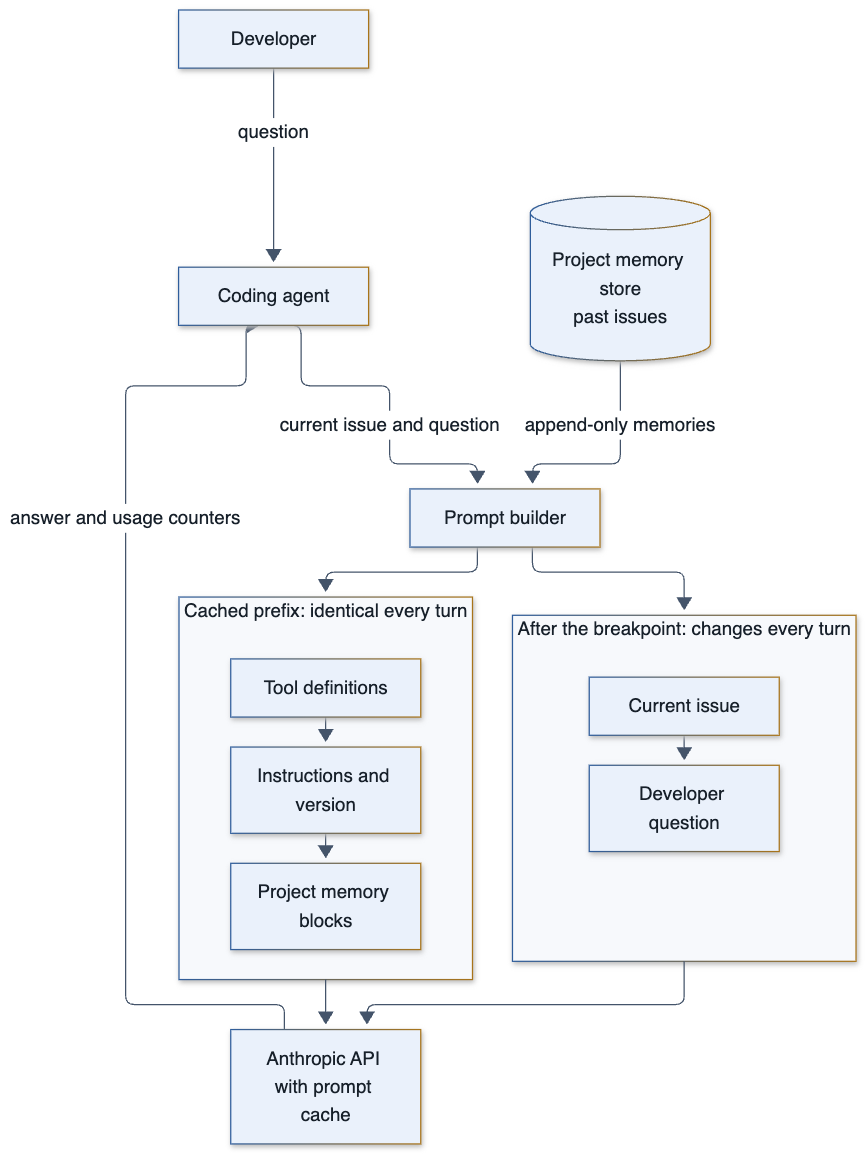

<details><summary>Mermaid source</summary>

```mermaid
flowchart TB
    Dev["Developer"] -->|"question"| Agent["Coding agent"]
    Store[("Project memory store<br/>past issues")] -->|"append-only memories"| Builder["Prompt builder"]
    Agent -->|"current issue and question"| Builder
    subgraph Prefix["Cached prefix: identical every turn"]
        T["Tool definitions"] --> I["Instructions and version"] --> M["Project memory blocks"]
    end
    subgraph Suffix["After the breakpoint: changes every turn"]
        W["Current issue"] --> Q["Developer question"]
    end
    Builder --> Prefix
    Builder --> Suffix
    Prefix --> API["Anthropic API with prompt cache"]
    Suffix --> API
    API -->|"answer and usage counters"| Agent
```

</details>

### Takeaways

- Instructions, tools and durable project memory are the same on every turn: they form the cached prefix.
- The current task and anything request-specific go after the breakpoint.
- Memory stays in your own store; the prompt cache only reuses the provider's work on its current text.

# Part 3 · Set up

## 3.1 · Imports

The notebook uses the raw Anthropic SDK for every model call, pandas (with `huggingface_hub` and
`pyarrow` underneath) to read the public dataset, and the standard library for timing and identifiers.
The warning filter hides a progress-bar notice from the dataset download that does not affect results.

In [2]:
import math
import os
import time
import uuid
import warnings
from datetime import datetime, timezone
from getpass import getpass

import pandas as pd
from anthropic import Anthropic
from IPython.display import display

warnings.filterwarnings("ignore", message="IProgress not found")

### Read private keys safely

`secret()` asks for a key with `getpass`, so the value is never echoed into the notebook
or saved with its outputs. Automated runs can set `NOTEBOOK_USE_ENV_KEYS=1` to read the
same name from an environment variable instead. An empty value stops the notebook early
with a clear error rather than failing later inside a provider call.

In [3]:
def secret(name):
    """Return a private key from a hidden prompt, or from the environment in automated runs."""
    if os.getenv("NOTEBOOK_USE_ENV_KEYS") == "1":
        value = os.getenv(name, "")
    else:
        value = getpass(f"Enter {name}: ")
    if not value.strip():
        raise ValueError(f"{name} is required.")
    return value.strip()

## 3.2 · Prices and the measurement ledger

Prompt caching has five prices, not two. The values are Claude Opus 5.5 list prices in USD per million
tokens (checked on 2026-10-03): ordinary input, a 5-minute cache write, a 1-hour cache write, a cache read
and output. `MEASUREMENTS` collects one row per agent turn. A per-run marker, `RUN_MARKER`, is added to the
instructions later; it guarantees that this run starts with an empty cache even if you ran the notebook a
minute ago, so the first cached turn really is a write.

In [4]:
MODEL = "claude-opus-5-5"
PRICE = {
    "input": 4.00,
    "write_5m": 5.00,
    "write_1h": 8.00,
    "read": 0.20,
    "output": 20.00,
}
MEASUREMENTS = []
RUN_MARKER = uuid.uuid4().hex[:12]
print("Run marker:", RUN_MARKER)

Run marker: a2644f8f9e4f


## 3.3 · Price one response from its counters

`llm_cost()` reads the usage object returned with every response. `cache_creation_input_tokens` is the
total written; the `cache_creation` breakdown says how much of it went to the 1-hour lifetime, which is
priced higher. The function returns the split token counts and the estimated cost.

`uncached_cost()` prices the same tokens as if caching did not exist: every prompt token at the ordinary
input price. Comparing the two answers "what did the cache save on this turn?".

In [5]:
def llm_cost(usage):
    """Split the reported counters by price; return (tokens, estimated USD)."""
    created = getattr(usage, "cache_creation", None)
    write_1h = (created.ephemeral_1h_input_tokens or 0) if created else 0
    tokens = {
        "input": usage.input_tokens,
        "write_5m": (usage.cache_creation_input_tokens or 0) - write_1h,
        "write_1h": write_1h,
        "read": usage.cache_read_input_tokens or 0,
        "output": usage.output_tokens,
    }
    return tokens, sum(tokens[k] * PRICE[k] for k in tokens) / 1_000_000


def uncached_cost(tokens):
    """Price the same request as if every prompt token were ordinary input."""
    prompt = tokens["input"] + tokens["write_5m"] + tokens["write_1h"] + tokens["read"]
    return (prompt * PRICE["input"] + tokens["output"] * PRICE["output"]) / 1_000_000

## 3.4 · Create the Anthropic client

The key is read with `secret()` and kept in the client object only. A 120-second timeout and two retries
keep a slow network from hanging the notebook.

In [6]:
claude = Anthropic(api_key=secret("ANTHROPIC_API_KEY"), timeout=120, max_retries=2)

## 3.5 · Load the repository's issues

SWE-bench Lite is a public dataset of 300 real GitHub issues from popular Python projects. The URL pins a
dataset **revision** (a commit of the dataset repository), so the rows never change under you. Only four
columns are read, and only the django/django issues are kept, oldest first.

In [7]:
SWE_BENCH = "hf://datasets/SWE-bench/SWE-bench_Lite@b0dde1093fe417d83b7184254edf8199c1f0dff5/data/test-00000-of-00001.parquet"
columns = ["instance_id", "repo", "created_at", "problem_statement"]
issues = pd.read_parquet(SWE_BENCH, columns=columns)
django = (
    issues[issues.repo == "django/django"]
    .sort_values("created_at")
    .reset_index(drop=True)
)
print(len(issues), "issues in the dataset;", len(django), "from django/django")
display(django[["instance_id", "created_at"]].head(3))

300 issues in the dataset; 114 from django/django


,instance_id,created_at
0,django__django-10914,2019-01-30T13:13:20Z
1,django__django-10924,2019-02-03T11:30:12Z
2,django__django-11001,2019-02-17T13:02:09Z


## 3.6 · Split the issues into memory and today's work

- `MEMORIES`: the ten oldest django issues. They play the part of what the agent already knows about the
  repository, its long-term project memory.
- `NEW_MEMORY`: the eleventh issue, which the agent "learns" halfway through the run.
- `CURRENT`: the newest django issue. This is today's task: working memory, sent after the breakpoint.

In [8]:
MEMORIES = [row for _, row in django.iloc[:10].iterrows()]
NEW_MEMORY = django.iloc[10]
CURRENT = django.iloc[-1]
print("Current issue:", CURRENT.instance_id)
print(CURRENT.problem_statement[:400])

Current issue: django__django-17087
Class methods from nested classes cannot be used as Field.default.
Description
	 
		(last modified by Mariusz Felisiak)
	 
Given the following model:
 
class Profile(models.Model):
	class Capability(models.TextChoices):
		BASIC = ("BASIC", "Basic")
		PROFESSIONAL = ("PROFESSIONAL", "Professional")
		
		@classmethod
		def default(cls) -> list[str]:
			return [cls.BASIC]
	capabilities = ArrayField(



# Part 4 · Build the cached prompt

## 4.1 · Tool definitions

The agent can read files, search code and run tests. `tool()` builds one definition in the shape the
Messages API expects: a name, a description and a JSON schema for the input. Tools are the very first part
of the cached prefix, so their order and wording must be stable: build them from code, never from a
dictionary whose order might change.

In this notebook every turn uses `tool_choice={"type": "none"}`: the model knows the tools exist but answers
in text. The breakpoint sits in `system`, so changing `tool_choice` would not invalidate this cached
prefix: it affects only cached `messages` blocks. It is still kept identical on every turn, so an agent
that also caches its conversation history keeps those blocks too.

In [9]:
def tool(name, description, **params):
    """One tool definition; every parameter is a required string."""
    properties = {
        key: {"type": "string", "description": text} for key, text in params.items()
    }
    schema = {"type": "object", "properties": properties, "required": list(params)}
    return {"name": name, "description": description, "input_schema": schema}

The three tools, built in a fixed order. Each description is short and stable: a reworded description is a
different prefix.

In [10]:
TOOLS = [
    tool("read_file", "Read a repository file.", path="Relative file path."),
    tool("search_code", "Search the repository.", query="Text or symbol to find."),
    tool("run_tests", "Run Django tests.", label="Test label, e.g. migrations."),
]

## 4.2 · Instructions with a version

The instructions are procedural memory: how the agent should behave. `PROMPT_VERSION` makes deliberate
changes visible; bumping it is how you knowingly start a new cache entry. `RUN_MARKER` keeps this run's
entries separate from any earlier run.

In [11]:
PROMPT_VERSION = "repo-agent-v1"
INSTRUCTIONS = f"""You are a coding agent for the django/django repository.
Use the project memory below: each entry summarises an issue you have already worked on.
Answer the developer's question about the current issue in at most three sentences.
Cite memory entries by their ID when you rely on them. You have not run any tool in this turn,
so never claim to have read files or run tests.
Prompt version: {PROMPT_VERSION}. Run marker: {RUN_MARKER}."""

## 4.3 · One memory entry per block

`memory_text()` turns an issue into a compact memory entry: its ID, the date it was opened and the first
800 characters of the description with whitespace collapsed. Collapsing whitespace makes the text
deterministic, which matters because a single changed space would be a cache miss.

In [12]:
def memory_text(issue, limit=800):
    """A compact, deterministic memory entry for one past issue."""
    body = " ".join(issue.problem_statement.split())[:limit]
    return f"Memory {issue.instance_id} (opened {issue.created_at[:10]}): {body}"


print(memory_text(MEMORIES[0])[:300])

Memory django__django-10914 (opened 2019-01-30): Set default FILE_UPLOAD_PERMISSION to 0o644. Description Hello, As far as I can see, the ​File Uploads documentation page does not mention any permission issues. What I would like to see is a warning that in absence of explicitly configured FILE_UPLOA


## 4.4 · Assemble the system blocks and place the breakpoint

`system_blocks()` returns the `system` parameter as a list of text blocks: the instructions first, then one
block per memory. Keeping memories in **separate blocks** is deliberate: when a new memory is appended later,
the API can find the entry written at the previous last block and reuse it.

- `ttl=None` sends no breakpoint at all, so nothing is cached.
- `ttl="5m"` or `ttl="1h"` puts `cache_control` on the **last** block, so the whole system prompt (and the
  tools before it) becomes the cached prefix.
- `header` inserts an extra block at the very start. It is used twice later: once to show what a volatile
  value does when it is placed before the breakpoint, and once to give the one-hour test its own prefix.

In [13]:
def system_blocks(memories, ttl=None, header=None):
    """Instructions, then one block per memory; the breakpoint goes on the last block."""
    texts = (
        ([header] if header else [])
        + [INSTRUCTIONS]
        + [memory_text(m) for m in memories]
    )
    blocks = [{"type": "text", "text": text} for text in texts]
    if ttl:
        blocks[-1]["cache_control"] = {"type": "ephemeral", "ttl": ttl}
    return blocks

## 4.5 · Working memory goes after the breakpoint

The user message carries what changes on every turn: the current issue and the developer's question.
Because it comes after the breakpoint, it is always processed fresh and billed as ordinary `input_tokens`;
it can change freely without affecting the cached prefix.

In [14]:
def working_memory(question):
    """The changing part of the prompt: today's issue and the developer's question."""
    issue = " ".join(CURRENT.problem_statement.split())[:1500]
    return f"Current issue {CURRENT.instance_id}:\n{issue}\n\nDeveloper question: {question}"

## 4.6 · Check that the prefix is long enough

The token-counting endpoint measures a request without running the model, so it costs no generation. The
first number is the whole prompt; the second is the same request with no memories. The difference is the
project memory, and the whole stable part must be above the 512-token minimum for Claude Opus 5.5.

**What to watch:** the full prompt is several thousand tokens and the memory blocks are most of it, so the
prefix is far above the minimum.

In [15]:
def prompt_tokens(system):
    """Count the input tokens of a turn without generating anything."""
    return claude.messages.count_tokens(
        model=MODEL,
        tools=TOOLS,
        tool_choice={"type": "none"},
        system=system,
        messages=[{"role": "user", "content": working_memory("placeholder")}],
    ).input_tokens


full, without_memory = prompt_tokens(system_blocks(MEMORIES)), prompt_tokens(
    system_blocks([])
)
print(f"Full prompt: {full} tokens; project memory adds {full - without_memory} tokens")

Full prompt: 3831 tokens; project memory adds 2726 tokens


## 4.7 · Record one turn

`record()` turns a response's usage into one `MEASUREMENTS` row: latency, the four counters (the two write
lifetimes are added together as `cache_write_tokens`), the estimated cost and the no-cache cost of the same
tokens.

In [16]:
def record(step, seconds, usage):
    """Append one row with the counters, the estimated cost and the no-cache cost."""
    tokens, usd = llm_cost(usage)
    row = {"step": step, "seconds": round(seconds, 2), "llm_calls": 1}
    row["input_tokens"] = tokens["input"]
    row["cache_write_tokens"] = tokens["write_5m"] + tokens["write_1h"]
    row["cache_write_1h_tokens"] = tokens["write_1h"]
    row["cache_read_tokens"] = tokens["read"]
    row["output_tokens"] = tokens["output"]
    row["estimated_usd"] = round(usd, 6)
    row["uncached_usd"] = round(uncached_cost(tokens), 6)
    MEASUREMENTS.append(row)
    return row

## 4.8 · Run one agent turn

`ask_agent()` sends one turn with the tools, the given system blocks and the working memory. Everything
else is held constant on purpose: model, `max_tokens`, `tool_choice` and the low effort setting. It prints
the four counters and returns the answer text.

In [17]:
def ask_agent(step, system, question):
    """One agent turn; prints the usage counters and returns the answer."""
    started = time.perf_counter()
    response = claude.messages.create(
        model=MODEL,
        max_tokens=400,
        tools=TOOLS,
        tool_choice={"type": "none"},
        system=system,
        messages=[{"role": "user", "content": working_memory(question)}],
        output_config={"effort": "low"},
    )
    row = record(step, time.perf_counter() - started, response.usage)
    keys = ["input_tokens", "cache_write_tokens", "cache_read_tokens", "output_tokens"]
    print({key: row[key] for key in keys})
    return "".join(block.text for block in response.content if block.type == "text")

# Part 5 · Run the agent with and without the cache

## 5.1 · Turn 1 · no breakpoint

The baseline: the same prompt with no `cache_control`. Everything is processed and billed as ordinary input.

**What to watch:** `cache_write_tokens` and `cache_read_tokens` are both 0, and `input_tokens` is the whole
prompt, within a few tokens of what the token counter reported (only the question text differs).

In [18]:
Q_SUMMARY = "In two sentences: what is the current issue, and which Django component is most likely involved?"
print(ask_agent("1 · no breakpoint", system_blocks(MEMORIES), Q_SUMMARY))

{'input_tokens': 3852, 'cache_write_tokens': 0, 'cache_read_tokens': 0, 'output_tokens': 266}
The migration autodetector writes a classmethod on a nested class used as `Field.default` (here `Profile.Capability.default`) as `appname.models.Capability.default`, dropping the outer class, so the migration fails when it runs. The part most likely involved is the migration serializer in `django/db/migrations/serializer.py`, probably `FunctionTypeSerializer`: for bound methods it seems to build the path from `klass.__name__` rather than `__qualname__`. This is my guess from the issue text, since I haven't opened the code or run tests; django__django-10924 was also about how callables get written into migrations.


## 5.2 · Turn 2 · first cached turn writes the prefix

The same question with a 5-minute breakpoint on the last memory block. Nothing is cached yet for this run's
prefix, so the API processes it and writes an entry.

**What to watch:** `cache_write_tokens` holds almost the whole prompt, `cache_read_tokens` is 0, and
`input_tokens` shrinks to the working memory after the breakpoint. The prompt part of this turn costs *more*
than in turn 1, because written tokens are billed at 1.25× the input price.

In [19]:
cached_system = system_blocks(MEMORIES, ttl="5m")
print(ask_agent("2 · first cached turn", cached_system, Q_SUMMARY))

{'input_tokens': 522, 'cache_write_tokens': 3330, 'cache_read_tokens': 0, 'output_tokens': 344}
The issue is that when a nested class's classmethod (here `Profile.Capability.default`) is used as a field's `default`, the generated migration writes the wrong import path, `appname.models.Capability.default` instead of `appname.models.Profile.Capability.default`, so the migration fails when you run it. The most likely culprit is the migration serializer (`FunctionTypeSerializer` in `django/db/migrations/serializer.py`, from what I know of the codebase, since I haven't opened the file this turn), which probably builds the path from the class's `__name__` when it should use `__qualname__`; none of my memory entries cover this bug, though django__django-10924 also dealt with how callables get written into migrations.


## 5.3 · Turn 3 · a different question reads the prefix

The developer asks something else. The working memory changed, but everything before the breakpoint is
identical, so the entry written in turn 2 is reused. The answer is new; only the processing of the prefix
was skipped.

**What to watch:** `cache_read_tokens` equals turn 2's `cache_write_tokens`, `cache_write_tokens` is 0, and
the estimated cost drops well below turn 1's.

In [20]:
Q_SIMILAR = "Which memory entry is closest to the current issue, and why? Cite its ID."
print(ask_agent("3 · new question", cached_system, Q_SIMILAR))

{'input_tokens': 522, 'cache_write_tokens': 0, 'cache_read_tokens': 3330, 'output_tokens': 179}
The closest one is django__django-10924. That issue was about FilePathField's `path` and how migrations serialize a field argument: `makemigrations` wrote down a resolved value instead of a reference that could be imported. The current issue is also a serialization problem with a field argument (`default`) in a generated migration, where the reference is built wrong: it leaves out the outer class (`Capability.default` instead of `Profile.Capability.default`). The other entries are about unrelated areas like file permissions, ordering, media merging, validators or responses, so they don't help here.


## 5.4 · Turn 4 · the agent learns a new memory

The agent has finished another issue and its project memory grows by one entry. The new entry is appended
as a new block and the breakpoint moves to it. Because the earlier blocks are unchanged, the API looks back,
finds the entry that ends at the previous last block and reuses it; only the new block is written.

**What to watch:** `cache_read_tokens` is turn 3's prefix again, give or take a token at the block boundary
(the old prefix was reused), and `cache_write_tokens` is only the size of the one new memory block, a few
hundred tokens.

In [21]:
grown_system = system_blocks(MEMORIES + [NEW_MEMORY], ttl="5m")
Q_TOOL = "Which tool would you call first, and with which argument? Describe the call in one sentence."
print(ask_agent("4 · new memory appended", grown_system, Q_TOOL))

{'input_tokens': 523, 'cache_write_tokens': 302, 'cache_read_tokens': 3329, 'output_tokens': 155}
I'd start with `read_file` on `django/db/migrations/serializer.py`, since that's most likely where the serializer for bound methods builds the import path from `__name__` rather than `__qualname__`, which would drop the `Profile.` prefix. This is my guess from how Django usually works, not something I've checked: I haven't opened any files yet. None of the memory entries cover this serializer, though django__django-10924 was a similar migrations issue about a field argument that took a callable.


## 5.5 · Turn 5 · a volatile value before the breakpoint

A common mistake: putting something that changes on every request, such as the current time, at the start
of the system prompt. Every block after it now has a different prefix, so no earlier entry can match, even
though the instructions and memories are exactly the same as in turn 4.

**What to watch:** `cache_read_tokens` is 0 and `cache_write_tokens` is the whole prompt again. With a
timestamp at the start, every turn would pay this write premium and never read. The fix is to send such
values in the working memory, after the breakpoint.

In [22]:
now = datetime.now(timezone.utc).isoformat(timespec="seconds")
volatile_system = system_blocks(
    MEMORIES + [NEW_MEMORY], ttl="5m", header=f"Request time: {now}"
)
Q_RISK = "Name two risks of changing how migrations serialize field defaults, one sentence each."
print(ask_agent("5 · volatile value first", volatile_system, Q_RISK))

{'input_tokens': 523, 'cache_write_tokens': 3652, 'cache_read_tokens': 0, 'output_tokens': 316}
1. **Existing migrations could break or change:** if the serializer starts writing a different import path for callable defaults (for example, switching from `__name__` to `__qualname__` for bound class methods), running `makemigrations` again may create unexpected migrations for unchanged models, or produce paths that don't import where the old ones did. This is the same kind of problem as django__django-10924, where the value a migration captures for a field argument varies with how it was resolved.
2. **Other callables could be serialized wrongly:** a broader change to how methods are serialized might accidentally cover cases that should still fail or stay as they are, such as instance methods, locally defined functions (`<locals>` in the qualname) or classes nested inside functions, producing migrations that only fail later when they're applied.


## 5.6 · Turn 6 · a one-hour cache write

For traffic with gaps longer than five minutes, a one-hour lifetime keeps the entry alive between turns. The
`header` gives this turn its own stable prefix so it writes a fresh entry instead of reading the 5-minute
one, which makes the price of a one-hour write visible.

**What to watch:** the write appears in `cache_write_1h_tokens` in the table below, priced at 2× the input
price instead of 1.25×.

In [23]:
hour_system = system_blocks(
    MEMORIES + [NEW_MEMORY], ttl="1h", header="Cache tier: one hour"
)
print(ask_agent("6 · one-hour write", hour_system, Q_SIMILAR))

{'input_tokens': 522, 'cache_write_tokens': 3641, 'cache_read_tokens': 0, 'output_tokens': 131}
The closest memory entry is django__django-10924, which was about letting FilePathField's `path` accept a callable. Both issues are about how a field argument gets written into a migration: there, `makemigrations` baked in a machine-specific path. Here, the migration serializer writes `Capability.default` with the wrong path, leaving out the outer `Profile` class (it should use the nested class's `__qualname__`).


# Part 6 · Results, limits and production notes

## 6.1 · The ledger

One row per turn. `estimated_usd` is what the turn cost at list prices; `uncached_usd` is what the same
tokens would have cost with no caching at all.

**What to watch:** turns 2, 5 and 6 cost more than their `uncached_usd` (they wrote), turn 3 costs much less
(it read), and turn 4 costs less because it read the old prefix and wrote only one block.

In [24]:
results = pd.DataFrame(MEASUREMENTS)
display(results.drop(columns=["llm_calls"]))

,step,seconds,input_tokens,cache_write_tokens,cache_write_1h_tokens,cache_read_tokens,output_tokens,estimated_usd,uncached_usd
0,1 · no breakpoint,4.05,3852,0,0,0,266,0.020728,0.020728
1,2 · first cached turn,5.95,522,3330,0,0,344,0.025618,0.022288
2,3 · new question,3.75,522,0,0,3330,179,0.006334,0.018988
3,4 · new memory appended,3.56,523,302,0,3329,155,0.007368,0.019716
4,5 · volatile value first,5.48,523,3652,0,0,316,0.026672,0.023020
5,6 · one-hour write,3.31,522,3641,3641,0,131,0.033836,0.019272


## 6.2 · What the cache saved on the normal path

Turns 2, 3 and 4 are the pattern a real agent follows: write once, then read on every later turn while the
prefix stays the same. The cell compares their actual cost with the no-cache cost of the same tokens.

**What to watch:** even with one write and only two reads, the cached turns cost less in total than the same
turns without caching. Every additional read within the lifetime widens the gap.

In [25]:
normal_path = results[results.step.str[0].isin(["2", "3", "4"])]
actual, without = normal_path.estimated_usd.sum(), normal_path.uncached_usd.sum()
print(f"Turns 2–4 actual: ${actual:.4f}; without caching: ${without:.4f}")
print(f"Saved: ${without - actual:.4f} ({100 * (without - actual) / without:.0f}%)")

Turns 2–4 actual: $0.0393; without caching: $0.0610
Saved: $0.0217 (36%)


## 6.3 · The break-even point

A write costs a premium over ordinary input; each read saves the difference between the input price and
the read price. Dividing one by the other gives how many reads a write needs before it pays for itself.

**What to watch:** on Claude Opus 5.5 a 5-minute write pays for itself after one read, and a one-hour write
after two.

In [26]:
saving_per_read = PRICE["input"] - PRICE["read"]
for lifetime in ["write_5m", "write_1h"]:
    premium = PRICE[lifetime] - PRICE["input"]
    reads = math.ceil(premium / saving_per_read)
    print(
        f"{lifetime}: premium ${premium:.2f}/MTok, each read saves ${saving_per_read:.2f}/MTok "
        f"→ pays back after {reads} read(s)"
    )

write_5m: premium $1.00/MTok, each read saves $3.80/MTok → pays back after 1 read(s)
write_1h: premium $4.00/MTok, each read saves $3.80/MTok → pays back after 2 read(s)


## 6.4 · Production notes

- **Order the prompt by stability.** Tools, then instructions, then durable memory, then the breakpoint, then
  the current task. Build tool lists and memory blocks deterministically (fixed order, normalised whitespace).
- **Version the prefix.** Put a prompt version in the instructions and change it on purpose. Unexplained
  cache writes in your metrics usually mean something volatile slipped into the prefix.
- **Append, do not edit.** New memories go at the end as new blocks. Rewrite or reorder the memory section
  only when you accept a full write.
- **Monitor the counters.** Track `cache_read_input_tokens / (input + write + read)` per route. A falling ratio
  is a regression even when the answers look fine.
- **Choose the lifetime from traffic.** Use 5 minutes when turns arrive in bursts; use 1 hour when gaps are
  longer and each write is reused at least twice; skip the breakpoint for one-off requests.
- **Warm up before fanning out.** Parallel requests only hit after one response has started; send one first.
- **Keep settings constant.** A `tool_choice` change invalidates cached message blocks; effort and thinking
  changes invalidate message blocks and, on some models, the tools and system levels. Change them only
  together with a new prefix version.

## 6.5 · Close the client

Prompt-cache entries live at the provider and expire on their own, so there is nothing to delete. Closing the
client releases its network connections.

In [27]:
claude.close()
print("Closed. Turns measured:", len(MEASUREMENTS))

Closed. Turns measured: 6


### Takeaways

- The usage counters are the only evidence of prompt caching: read them on every turn.
- One write followed by reads is the profitable pattern; a prefix that changes every turn only adds cost.
- Append-only memory blocks let an agent's memory grow while still reusing most of the cached prefix.
- Prompt caching saves computation, not answers: every turn is still a fresh response to fresh working memory.